# Imports and data/model preparation

In [1]:
from config import PROCESSED_DATA_DIR, CSV_DATA_DIR, MODELS_DIR, PROJ_ROOT
from script.trainer import Trainer, EarlyStopping
from models.ViT import ViTClassifier_tiny
import torch
import torch.nn as nn
import torchmetrics.classification as metrics
from torch.utils.data import DataLoader
from script.dataset import MapDataset
from torch.optim import AdamW
from script.visualization import plot_history
import pandas as pd
from script.cross_validation import kfoldCV
import optuna
import joblib
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

2025-08-07 21:18:25.966 | INFO     | config:<module>:12 - PROJ_ROOT path is: /home/aislab/princisgh_map_completeness/map_completeness_estimation


## Visualize study parameters

In [2]:
study_file = PROJ_ROOT / 'studies/ViTClassifier_tiny_study'
study : optuna.Study = joblib.load(study_file, 'r')

In [3]:
(df := study.trials_dataframe())[df['state'] == 'COMPLETE']

,number,value,datetime_start,datetime_complete,duration,params_backbone_LR,params_batch_size,params_dropout,params_head_LR,params_head_layer_1,params_head_layer_2,params_num_layers,params_weight_decay,system_attrs_completed_rung_0,system_attrs_completed_rung_1,state
0,0,0.060191,2025-08-07 05:35:59.195516,2025-08-07 05:43:01.612321,0 days 00:07:02.416805,0.000002,64,0.0,0.000002,256,256.0,2,0.000046,0.072353,0.057563,COMPLETE
3,3,0.448708,2025-08-07 05:47:41.853597,2025-08-07 05:54:54.249470,0 days 00:07:12.395873,0.000002,64,0.4,0.009991,512,NaN,1,0.000118,0.447017,NaN,COMPLETE
4,4,0.365496,2025-08-07 05:54:59.508396,2025-08-07 06:06:41.985083,0 days 00:11:42.476687,0.000226,8,0.4,0.000020,1024,256.0,2,0.289659,0.349913,NaN,COMPLETE
5,5,0.053370,2025-08-07 06:06:47.408801,2025-08-07 06:13:49.852366,0 days 00:07:02.443565,0.000069,64,0.0,0.000002,2048,NaN,1,0.059006,0.052708,0.048386,COMPLETE
7,7,0.055968,2025-08-07 06:18:18.985721,2025-08-07 06:25:19.332674,0 days 00:07:00.346953,0.000002,128,0.0,0.000003,512,1024.0,2,0.000015,0.053834,NaN,COMPLETE
10,10,0.058418,2025-08-07 06:31:27.977654,2025-08-07 06:38:39.288441,0 days 00:07:11.310787,0.000027,64,0.0,0.000273,512,NaN,1,0.000948,0.051016,0.048289,COMPLETE
12,12,0.058514,2025-08-07 06:42:59.002454,2025-08-07 06:50:19.502107,0 days 00:07:20.499653,0.000002,128,0.0,0.000007,512,128.0,2,0.000012,0.056336,NaN,COMPLETE
20,20,0.076787,2025-08-07 07:11:10.798258,2025-08-07 07:18:13.023675,0 days 00:07:02.225417,0.000044,64,0.0,0.000002,512,NaN,1,0.002410,0.065046,NaN,COMPLETE
21,21,0.080166,2025-08-07 07:18:20.654859,2025-08-07 07:25:24.303672,0 days 00:07:03.648813,0.000178,64,0.0,0.000414,512,NaN,1,0.000062,0.059788,NaN,COMPLETE


In [4]:
params = study.best_params
print(params)

{'backbone_LR': 6.878931090166419e-05, 'head_LR': 2.20151864307412e-06, 'weight_decay': 0.05900648932449035, 'batch_size': 64, 'head_layer_1': 2048, 'num_layers': 1, 'dropout': 0.0}


In [5]:
optuna.visualization.plot_timeline(study)

## Prepare data and model for training

In [6]:
df_train = pd.read_csv(str(CSV_DATA_DIR / 'df_train.csv'))
df_val = pd.read_csv(str(CSV_DATA_DIR / 'df_valid.csv'))
df_test = pd.read_csv(str(CSV_DATA_DIR / 'df_test.csv'))

In [7]:
train_ds = MapDataset(PROCESSED_DATA_DIR / 'train', df_train, task='classification', augment=True)
val_ds = MapDataset(PROCESSED_DATA_DIR / 'valid', df_val, task='classification', )
test_ds = MapDataset(PROCESSED_DATA_DIR / 'test', df_test, task='classification', )

train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True, num_workers=8)
val_loader = DataLoader(val_ds, batch_size=params['batch_size'], num_workers=8)
test_loader = DataLoader(test_ds, batch_size=params['batch_size'], num_workers=8)

In [8]:
head_cfg = {
    'hidden_dims' : [2048],
    'dropout_rate': params['dropout']
}
model = ViTClassifier_tiny(img_size=224, head_cfg=head_cfg)
assert model.variant == 'tiny'

loss = torch.nn.CrossEntropyLoss()
ES = EarlyStopping(patience=4, restore_best_weights=True)
met = {
    "accuracy": metrics.BinaryAccuracy(),
    "precision": metrics.BinaryPrecision(),
    "recall": metrics.BinaryRecall(),
}

optim = AdamW([
    {'params': model.MLP.parameters(), 'lr': params['head_LR'], "weight_decay": params['weight_decay']},
    {'params': model.backbone.parameters(), 'lr': params['backbone_LR']}
])

EPOCHS = 30

for param in model.backbone.parameters():
    param.require_grad = True

trainer = Trainer(model, optim, loss, met)

#scheduler = torch.optim.lr_scheduler.MultiStepLR(optim, milestones=[10, 20], gamma=0.05)
#trainer.set_scheduler(scheduler)

Some weights of ViTModel were not initialized from the model checkpoint at WinKawaks/vit-tiny-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Compute CV loss

In [9]:
CVLoss = kfoldCV(
    trainer, 
    train_ds, 
    num_folds=5, 
    epochs=15, 
    batch_size=params['batch_size'], 
    task="classification", 
    ES=ES
)

print(f"k-Fold CV loss: {CVLoss:.5f}")


Epoch 1/15:   0%|          | 0/181 [00:00<?, ?it/s]

Starting fold 1/5


Evaluation:   0%|          | 0/46 [00:00<?, ?it/s]


Epoch 2/15:   0%|          | 0/181 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/46 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/46 [00:00<?, ?it/s]


Epoch 15/15:   0%|          | 0/181 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/46 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/46 [00:00<?, ?it/s]

Fold 5/5 ended with loss: 0.1327
5-fold CV loss: 0.1736
k-Fold CV loss: 0.17356


## Train classifier

In [10]:
trainer.reset_training()
trainer.train(train_loader, val_loader, 'classification', epochs=EPOCHS, early_stopping=ES)


Epoch 1/30:   0%|          | 0/226 [00:00<?, ?it/s]

[1/30] Train Loss: 0.2418


Evaluation:   0%|          | 0/52 [00:00<?, ?it/s]

	accuracy: 0.9446
	precision: 0.9463
	recall: 0.9426
[1/30] Val Loss: 0.1782 



Epoch 2/30:   0%|          | 0/226 [00:00<?, ?it/s]

...

	accuracy: 0.9438
	precision: 0.9476
	recall: 0.9396
[9/30] Val Loss: 0.1525 



Epoch 10/30:   0%|          | 0/226 [00:00<?, ?it/s]

[10/30] Train Loss: 0.1281


Evaluation:   0%|          | 0/52 [00:00<?, ?it/s]

	accuracy: 0.9301
	precision: 0.9352
	recall: 0.9242
[10/30] Val Loss: 0.1588 
Stopping training due to EarlyStopping


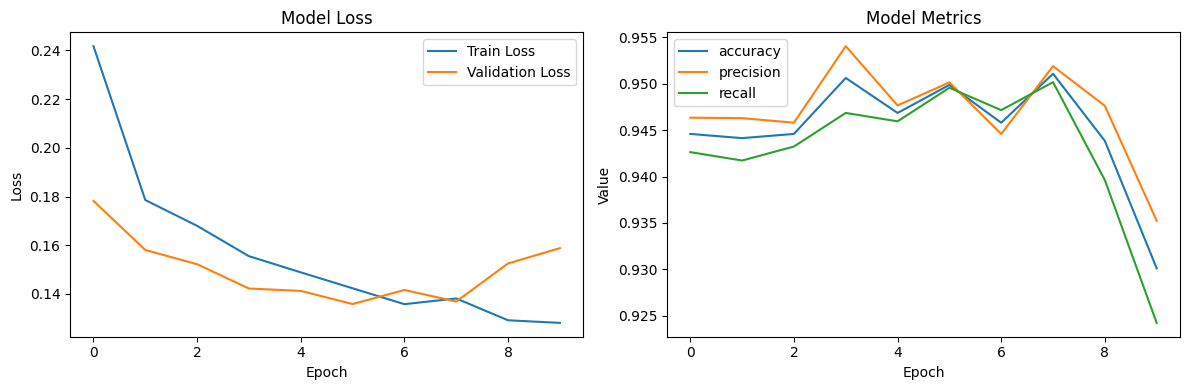

In [11]:
plot_history(trainer.history)

#### Validation Results

In [12]:
trainer.evaluate(val_loader) # run evaluation in case early stop was triggered
trainer.save_model(MODELS_DIR)

Evaluation:   0%|          | 0/52 [00:00<?, ?it/s]

	accuracy: 0.9499
	precision: 0.9502
	recall: 0.9496
Model ViTClassifier_tiny_classification.pt saved to /home/aislab/princisgh_map_completeness/map_completeness_estimation/model_weights


# Test result and metrics

In [13]:
y_hat, y_true, test_loss = trainer.predict(test_loader)
print(f'Test Loss: {test_loss}')

Evaluation:   0%|          | 0/48 [00:00<?, ?it/s]

W0807 17:17:34.256000 485014 torch/_dynamo/convert_frame.py:964] [16/8] torch._dynamo hit config.recompile_limit (8)
W0807 17:17:34.256000 485014 torch/_dynamo/convert_frame.py:964] [16/8]    function: 'torch_dynamo_resume_in_make_flat_list_of_images_at_244' (/home/aislab/princisgh_map_completeness/map_completeness_estimation/.venv/lib/python3.12/site-packages/transformers/image_utils.py:244)
W0807 17:17:34.256000 485014 torch/_dynamo/convert_frame.py:964] [16/8]    last reason: 16/2: len(images) == 64                                      
W0807 17:17:34.256000 485014 torch/_dynamo/convert_frame.py:964] [16/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0807 17:17:34.256000 485014 torch/_dynamo/convert_frame.py:964] [16/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.
W0807 17:17:34.259000 485014 torch/_dynamo/convert_frame.py:964] [22/8] torch._dynamo hit config.recompile_limit (8)
W0807 17:17:34.259000 485

Test Loss: 0.22235141950659454


In [14]:
import torch.nn as nn
y_hat_np = nn.Softmax()(y_hat)[:,0].numpy()
y_true_np = y_true[:,0].numpy()

/home/aislab/princisgh_map_completeness/map_completeness_estimation/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1751: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



In [15]:
def print_metrics(y_hat: np.ndarray, y_true: np.ndarray):
    print(classification_report(y_true, y_hat))
    print(f'Accuracy: {accuracy_score(y_true, y_hat)}')
    print(f'Precision: {precision_score(y_true, y_hat)}')
    print(f'Recall: {recall_score(y_true, y_hat)}')

    # confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_hat)
    #print cm values with labels
    cm_df = pd.DataFrame(cm, index=['Not Explored', 'Explored'], columns=['Not Explored', 'Explored'])
    print("Confusion Matrix DataFrame:")
    print(cm_df)

### Classification metrics for $\theta = 0.5$

In [16]:
y_hat_theta = (y_hat_np > 0.5).astype(float)
print_metrics(y_hat_theta, y_true_np)

              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91      1377
         1.0       0.96      0.88      0.92      1632

    accuracy                           0.92      3009
   macro avg       0.92      0.92      0.92      3009
weighted avg       0.92      0.92      0.92      3009

Accuracy: 0.9172482552342971
Precision: 0.960692871419054
Recall: 0.883578431372549
Confusion Matrix DataFrame:
              Not Explored  Explored
Not Explored          1318        59
Explored               190      1442


### Classification metrics for $\theta = 0.8$

In [17]:
y_hat_theta = (y_hat_np > 0.8).astype(float)
print_metrics(y_hat_theta, y_true_np)

              precision    recall  f1-score   support

         0.0       0.77      0.98      0.86      1377
         1.0       0.98      0.76      0.85      1632

    accuracy                           0.86      3009
   macro avg       0.87      0.87      0.86      3009
weighted avg       0.88      0.86      0.86      3009

Accuracy: 0.8584247258225324
Precision: 0.976303317535545
Recall: 0.7573529411764706
Confusion Matrix DataFrame:
              Not Explored  Explored
Not Explored          1347        30
Explored               396      1236


### Visualize ROC & AUROC

In [10]:
head_cfg = {
    'hidden_dims' : [2048],
    'dropout_rate': 0.0
}
model = ViTClassifier_tiny(224, head_cfg)

model.load_state_dict(torch.load(MODELS_DIR / 'ViTClassifier_tiny_classification.pt'))
model.eval()
trainer.model = model.to('cuda')

y_hat, y_true, test_loss = trainer.predict(test_loader)
print(f'Test Loss: {test_loss}')
import torch.nn as nn
y_hat_np = nn.Softmax()(y_hat)[:,0].numpy()
y_true_np = y_true[:,0].numpy()

Some weights of ViTModel were not initialized from the model checkpoint at WinKawaks/vit-tiny-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluation:   0%|          | 0/48 [00:00<?, ?it/s]

Test Loss: 0.22234998136991635


/home/aislab/princisgh_map_completeness/map_completeness_estimation/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1751: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



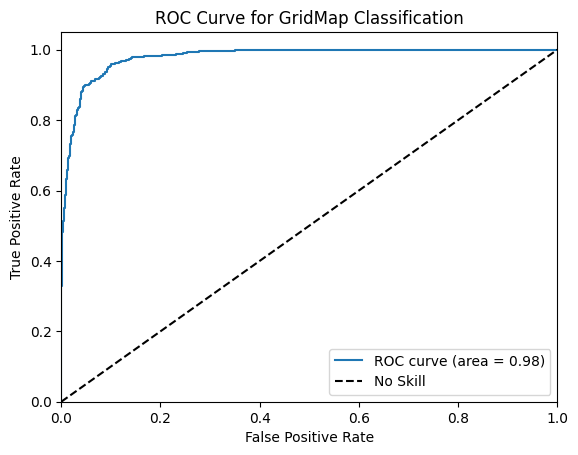

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true_np, y_hat_np)
roc_auc = auc(fpr, tpr)

plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for GridMap Classification')
plt.legend()
plt.show()